## Machine Learning Overview 
1. Data Scaling (Standardization)
Before any modeling occurs, the code uses a StandardScaler.

The Purpose: Statistics like Driving Distance (measured in hundreds of yards) and GIR% (measured in decimals) operate on completely different scales.

The Action: Standardization transforms all features so they have a mean of 0 and a standard deviation of 1, ensuring that "big numbers" don't unfairly overpower smaller, more precise percentages during the calculation.

2. Lasso Regression (Feature Selection)
The script applies Lasso (Least Absolute Shrinkage and Selection Operator) to determine which technical pillar is the best predictor of success.

How it works: Lasso adds a penalty to the model's coefficients. If a statistic (like Driving Distance) isn't strongly correlated with a lower score, Lasso will "shrink" its importance.

The Output: It produces a Predictor Ranking, which tells you mathematically which specific skill—Power, Precision, or Strokes Gained—is the most essential for a professional golfer to master.

3. K-Means Clustering (Strategic Archetypes)
This is an Unsupervised Learning step used to find natural patterns in the data.

The Process: The model looks at all players and groups them into three distinct "Clusters" based on similarities in their playstyles.

Defining Archetypes: It identifies "Profiles"—for example, one cluster might represent the "Bombers" (high distance, lower accuracy), while another represents "Tacticians" (shorter distance, high GIR%).

Evaluation: The code calculates a Silhouette Score to measure how well-defined these groups are, ensuring the players in each group actually share similar traits.

4. ROI Analysis (The Financial Verdict)
The final step bridges the gap between machine learning and business logic.

Success Metrics: The code aggregates the Money and Wins for each cluster.

The Goal: By comparing the average earnings of the "Bombers" versus the "Tacticians," the model provides a definitive "Return on Investment" (ROI) verdict, identifying which strategic style of play results in the highest paycheck on the PGA Tour.

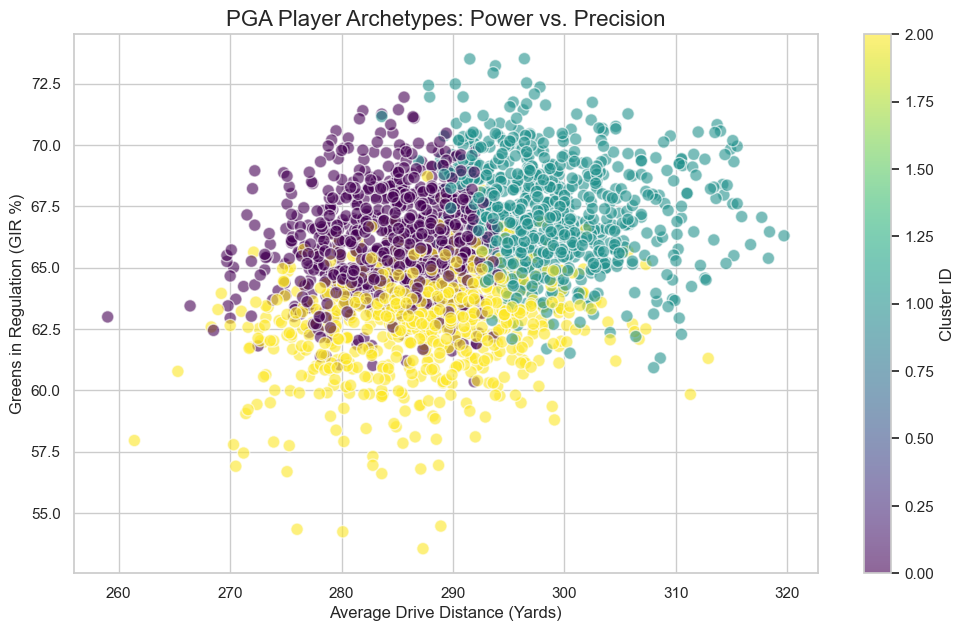

--- MACHINE LEARNING SUMMARY ---
Cluster Quality (Silhouette Score): 0.2373

Lasso Predictor Ranking:
              Feature  Standardized_Coefficient  Absolute_Importance
2            SG_Total                 -0.662967             0.662967
0  Avg_Drive_Distance                 -0.000000             0.000000
1      GIR_Percentage                 -0.000000             0.000000

ROI Analysis (Top 5 rows):
              Money                           Wins      Scoring_Avg
               mean     median           sum  mean  sum        mean
Cluster                                                            
0        1409147.18  1116507.0  1.162546e+09  0.17  139       70.76
1        2174747.25  1642124.0  1.624536e+09  0.39  290       70.51
2         675776.91   488940.0  4.595283e+08  0.08   57       71.57

All files exported to ../output/ folder.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, silhouette_score

# --- 1. SETUP & DATA RECOVERY ---
# Ensure output directories exist
os.makedirs('../output/figures', exist_ok=True)
os.makedirs('../output/tables', exist_ok=True)

# Load the cleaned dataset
# Path assumes this notebook is in the 'notebooks' folder
df = pd.read_csv('https://raw.githubusercontent.com/jachengl-alt/pgatour-performance-data/refs/heads/main/PGA_Data_Master_Cleaned.csv')

# Define the pillars from your project description
features = ['Avg_Drive_Distance', 'GIR_Percentage', 'SG_Total']
targets = ['Scoring_Avg', 'Money', 'Wins']

# Filter data: Keep only rows where we have all features and targets
ml_df = df.dropna(subset=features + targets).copy()

# --- 2. DATA SCALING (Class Exercise Format) ---
# Scaling is vital so that 'Distance' (large numbers) doesn't 
# overpower 'GIR' (decimals) in the models.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(ml_df[features])

# --- 3. LASSO REGRESSION (Variable Selection & Predictor Strength) ---
# This identifies which technical discipline is the strongest predictor
lasso = Lasso(alpha=0.01) 
lasso.fit(X_scaled, ml_df['Scoring_Avg'])

lasso_results = pd.DataFrame({
    'Feature': features,
    'Standardized_Coefficient': lasso.coef_,
    'Absolute_Importance': np.abs(lasso.coef_)
}).sort_values(by='Absolute_Importance', ascending=False)

# --- 4. K-MEANS CLUSTERING (Player Archetypes) ---
# Grouping players into 3 distinct strategic profiles
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
ml_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Calculate Silhouette Score to measure cluster quality
sil_avg = silhouette_score(X_scaled, ml_df['Cluster'])

# Extract Centroids (The "Average" stats for each profile)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=features)
centroid_df['Profile_Type'] = ['Profile 0', 'Profile 1', 'Profile 2']

# --- 5. ROI ANALYSIS (Success Metrics by Profile) ---
# This quantifies the "Return on Investment" for each strategic combination
roi_analysis = ml_df.groupby('Cluster').agg({
    'Money': ['mean', 'median', 'sum'],
    'Wins': ['mean', 'sum'],
    'Scoring_Avg': 'mean'
}).round(2)

# --- 6. VISUALIZATION: THE STRATEGIC LANDSCAPE ---
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Plot Distance vs. Accuracy, colored by Cluster (Profile)
scatter = plt.scatter(ml_df['Avg_Drive_Distance'], ml_df['GIR_Percentage'], 
            c=ml_df['Cluster'], cmap='viridis', alpha=0.6, edgecolors='w', s=80)

plt.colorbar(scatter, label='Cluster ID')
plt.title('PGA Player Archetypes: Power vs. Precision', fontsize=16)
plt.xlabel('Average Drive Distance (Yards)', fontsize=12)
plt.ylabel('Greens in Regulation (GIR %)', fontsize=12)

# Save the primary visual
plt.savefig('../output/figures/player_archetype_clusters.png', dpi=300)
plt.show()

# --- 7. EXPORTING THE STATISTICAL DATA ---
lasso_results.to_csv('../output/tables/lasso_feature_importance.csv', index=False)
centroid_df.to_csv('../output/tables/cluster_definitions.csv', index=False)
roi_analysis.to_csv('../output/tables/cluster_roi_performance.csv')

print("--- MACHINE LEARNING SUMMARY ---")
print(f"Cluster Quality (Silhouette Score): {sil_avg:.4f}")
print("\nLasso Predictor Ranking:")
print(lasso_results)
print("\nROI Analysis (Top 5 rows):")
print(roi_analysis.head())
print("\nAll files exported to ../output/ folder.")